# Flatten a Plot3D mesh into a finite-volume graph

This tutorial builds a **finite-volume graph** from a Plot3D multi-block
mesh: cells become graph nodes, and the faces between them become directed
`owner -> neighbor` edges carrying real geometry. That graph -- built by
`plot3d.flatmesh.flatten_mesh` -- is what a GPU CFD solver actually reads
and starts solving with.

Four short sections, in order:

1. **Connectivity, visually** -- what "flattening" means, before any code.
2. **Simple block** -- flatten one block, no connectivity or boundary
   conditions needed, and check every field by hand.
3. **Connected blocks** -- a real multi-block mesh, with periodicity.
4. **Exporting to simulation** -- tag the boundaries, see it at the node
   level, and write what a solver reads.

This notebook does **not** cover the `lb`/`ub` diagonal convention or the
8-permutation cross-plane system -- that's its own short notebook,
[`Plot3D_CrossPlaneConnectivity.ipynb`](Plot3D_CrossPlaneConnectivity.ipynb),
if you want the mechanics of how a face match is recorded. Nothing here
depends on it.


## Install

Requires **plot3d 1.10.0+**:


In [1]:
!pip install "plot3d>=1.10.0"


zsh:1: command not found: pip


In [2]:
import math
import os
import pprint

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from mpl_toolkits.mplot3d import Axes3D

from plot3d import Block, plot_blocks, flatten_mesh
from plot3d.connectivity import connectivity
from plot3d.periodicity import rotated_periodicity, create_rotation_matrix
from plot3d.glennht import (
    tag_surfaces_geometric,
    write_boundary_conditions_yaml,
    Plot3DFlattenInletBC,
    Plot3DFlattenOutletBC,
    Plot3DFlattenWallBC,
)

pp = pprint.PrettyPrinter(indent=2, width=100)
OUT_DIR = "flatten_out"
os.makedirs(OUT_DIR, exist_ok=True)


## 1. Connectivity, visually

A Plot3D mesh is a set of **blocks**, each a structured `(i, j, k)` grid of
nodes. Every node connects to its `i-1`/`i+1`, `j-1`/`j+1`, `k-1`/`k+1`
neighbors *within* its own block -- that part's simple. The interesting
part is *between* blocks: two blocks "connect" when one block's face sits
at the exact same physical location as another block's face.

That's the whole idea behind flattening. Below, two tiny blocks (8 nodes
each, just their corners) sit side by side. The orange nodes are one
block's face and the other block's face -- two *different* sets of nodes
that happen to sit at the same physical points. Flattening **welds** them
into one shared graph node, exactly like the dashed lines suggest:


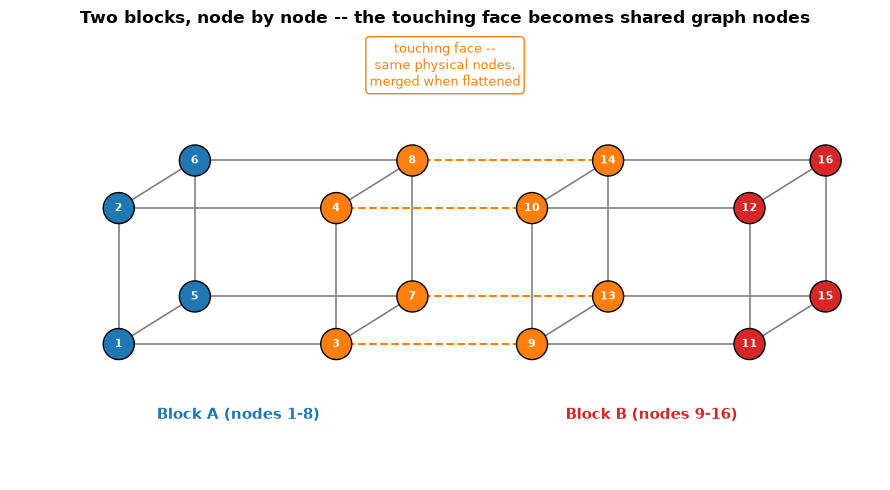

In [3]:
def cube_graph(base_id, x_origin, color):
    """8 corner nodes of a unit cube, id = base_id + 4*i + 2*j + k + 1,
    laid out with a slight (i-axis) skew so the cube reads as 3D on a flat
    2D plot. Returns the graph, its node positions, and the two node id
    lists for the j=0 and j=1 faces (the ones that can touch a neighbor)."""
    G = nx.Graph()
    pos, ids = {}, {}
    for i in (0, 1):
        for j in (0, 1):
            for k in (0, 1):
                nid = base_id + 4 * i + 2 * j + k + 1
                ids[(i, j, k)] = nid
                pos[nid] = (x_origin + j + 0.35 * i, k + 0.35 * i)
                G.add_node(nid)
    for i in (0, 1):
        for j in (0, 1):
            for k in (0, 1):
                for di, dj, dk in [(1, 0, 0), (0, 1, 0), (0, 0, 1)]:
                    ii, jj, kk = i + di, j + dj, k + dk
                    if ii <= 1 and jj <= 1 and kk <= 1:
                        G.add_edge(ids[(i, j, k)], ids[(ii, jj, kk)])
    face_j0 = [ids[(i, 0, k)] for i in (0, 1) for k in (0, 1)]
    face_j1 = [ids[(i, 1, k)] for i in (0, 1) for k in (0, 1)]
    return G, pos, face_j0, face_j1


GA, posA, A_j0, A_j1 = cube_graph(base_id=0, x_origin=0.0, color="tab:blue")
GB, posB, B_j0, B_j1 = cube_graph(base_id=8, x_origin=1.9, color="tab:red")
G = nx.compose(GA, GB)
pos = {**posA, **posB}

touching = set(A_j1) | set(B_j0)
node_colors = ["tab:orange" if n in touching else ("tab:blue" if n <= 8 else "tab:red") for n in G.nodes]

fig, ax = plt.subplots(figsize=(9, 5))
nx.draw_networkx_edges(G, pos, ax=ax, edge_color="gray", width=1.2)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=500,
                       edgecolors="black", linewidths=1.0)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, font_color="white", font_weight="bold")

# weld lines: block A's j=1 face node <-> the matching block B j=0 face
# node (matched by (i, k), i.e. "the corner in the same spot")
for a, b in zip(A_j1, B_j0):
    xa, ya = pos[a]
    xb, yb = pos[b]
    ax.plot([xa, xb], [ya, yb], linestyle="--", color="tab:orange", linewidth=1.5, zorder=0)

ax.text(0.55, -0.55, "Block A (nodes 1-8)", ha="center", fontsize=11, fontweight="bold", color="tab:blue")
ax.text(2.45, -0.55, "Block B (nodes 9-16)", ha="center", fontsize=11, fontweight="bold", color="tab:red")
ax.text(1.5, 1.9, "touching face --\nsame physical nodes,\nmerged when flattened",
        ha="center", fontsize=9, color="tab:orange",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="tab:orange"))
ax.set_title("Two blocks, node by node -- the touching face becomes shared graph nodes",
             fontsize=12, fontweight="bold")
ax.axis("off")
ax.set_xlim(-0.5, 3.5)
ax.set_ylim(-1.0, 2.3)
plt.tight_layout()
plt.show()


That's it -- that's flattening. `plot3d.connectivity.connectivity()` finds
*which* faces touch (comparing every block's exterior faces against every
other block's). `plot3d.flatmesh.flatten_mesh` does the welding above for
real, across an entire mesh, and turns every cell into a graph node along
the way.

*(If you want to know exactly how a touching face gets recorded --
the `lb`/`ub` corners, the orientation flags -- that's
[`Plot3D_CrossPlaneConnectivity.ipynb`](Plot3D_CrossPlaneConnectivity.ipynb).
Not needed here.)*


## 2. Simple block

`flatten_mesh` needs three things: `blocks`, `face_matches`, and
`outer_faces`. For a single block there's nothing to match --
`face_matches` is empty, and all 6 sides are `outer_faces`. No connectivity
puzzle, no periodicity, and **no boundary conditions required at all** --
a graph exists the moment you have a mesh; boundary conditions just label
parts of it later (Section 4).

`duct_block` builds one block: a straight rectangular duct. `height` can
be a constant (this section) or a function of `x` -- a converging-diverging
profile, which is exactly what a follow-on Euler-solver tutorial reuses
this same generator for.


one block: (9, 5, 3) nodes


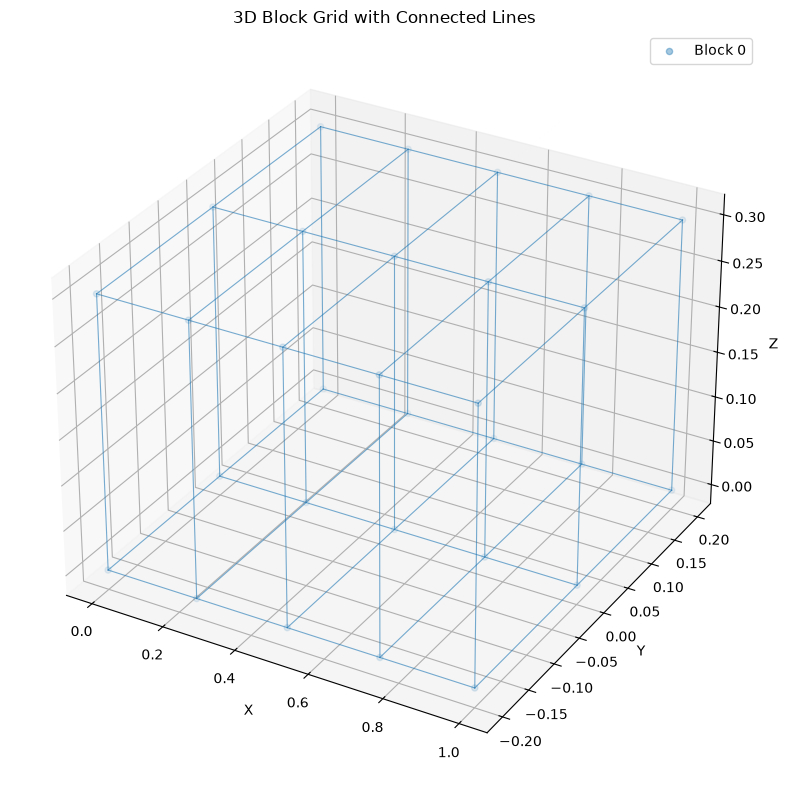

In [4]:
def duct_block(x0, x1, nx, height, ny=9, nz=5, depth=0.3):
    """A single-block rectangular duct. `height` is the full duct height at
    each x station: a constant for a straight duct, or a callable height(x)
    for a variable cross-section. `depth` is a fixed z-extent, kept small
    so cell volumes stay easy to check by hand."""
    x = np.linspace(x0, x1, nx)
    z = np.linspace(0.0, depth, nz)
    X = np.zeros((nx, ny, nz))
    Y = np.zeros_like(X)
    Z = np.zeros_like(X)
    for i in range(nx):
        h = height(x[i]) if callable(height) else height
        y = np.linspace(-h / 2, h / 2, ny)
        for j in range(ny):
            for k in range(nz):
                X[i, j, k] = x[i]
                Y[i, j, k] = y[j]
                Z[i, j, k] = z[k]
    return Block(X, Y, Z)


blk = duct_block(0.0, 1.0, 9, height=0.4, ny=5, nz=3)
print(f"one block: ({blk.IMAX}, {blk.JMAX}, {blk.KMAX}) nodes")
plot_blocks([blk])


Flatten it. `connectivity()` still runs -- with one block it just returns
an empty `face_matches` and all 6 sides as `outer_faces`, so the same code
path works whether you have 1 block or 100:


In [5]:
face_matches, outer_faces = connectivity([blk])
print(f"face_matches: {len(face_matches)}   outer_faces: {len(outer_faces)}")

fmesh = duct_flat = flatten_mesh([blk], face_matches, outer_faces)
print(fmesh.summary())


0it [00:00, ?it/s]

0it [00:00, ?it/s]

Phase 3: Fresh-face validation...
  Phase 3 done (0 new matches)
face_matches: 0   outer_faces: 6


Calculating the volumes:   0%|          | 0/2 [00:00<?, ?it/s]

Calculating the volumes: 100%|██████████| 2/2 [00:00<00:00, 3407.23it/s]

FlatMesh: Nc=64 Nf=248 Nn=135
  total volume = 0.12
  total boundary surface area = 1.64
  periodic faces = 0
  boundary faces per surface:
    id=1 (1): 16
    id=2 (2): 8
    id=3 (3): 32
    id=4 (4): 16
    id=5 (5): 32
    id=6 (6): 8


In [6]:
fmesh.cell_ijk

array([[0, 0, 0],
       [1, 0, 0],
       [2, 0, 0],
       [3, 0, 0],
       [4, 0, 0],
       [5, 0, 0],
       [6, 0, 0],
       [7, 0, 0],
       [0, 1, 0],
       [1, 1, 0],
       [2, 1, 0],
       [3, 1, 0],
       [4, 1, 0],
       [5, 1, 0],
       [6, 1, 0],
       [7, 1, 0],
       [0, 2, 0],
       [1, 2, 0],
       [2, 2, 0],
       [3, 2, 0],
       [4, 2, 0],
       [5, 2, 0],
       [6, 2, 0],
       [7, 2, 0],
       [0, 3, 0],
       [1, 3, 0],
       [2, 3, 0],
       [3, 3, 0],
       [4, 3, 0],
       [5, 3, 0],
       [6, 3, 0],
       [7, 3, 0],
       [0, 0, 1],
       [1, 0, 1],
       [2, 0, 1],
       [3, 0, 1],
       [4, 0, 1],
       [5, 0, 1],
       [6, 0, 1],
       [7, 0, 1],
       [0, 1, 1],
       [1, 1, 1],
       [2, 1, 1],
       [3, 1, 1],
       [4, 1, 1],
       [5, 1, 1],
       [6, 1, 1],
       [7, 1, 1],
       [0, 2, 1],
       [1, 2, 1],
       [2, 2, 1],
       [3, 2, 1],
       [4, 2, 1],
       [5, 2, 1],
       [6, 2, 1],
       [7,

`flatten_mesh` returns a `FlatMesh`: plain numpy arrays, structure-of-arrays
style -- easy to hand to any tool, no graph library required. On a mesh
this small, every field's value is checkable by hand:

- `points` `(Nn, 3)` -- node coordinates.
- `cell_volume`/`cell_centroid`/`cell_vertices` `(Nc, ...)` -- one hexahedron
  per structured `(block, i, j, k)` cell. `cell_block_id`/`cell_ijk` say
  which block and which structured index each cell came from.
- `face_owner`/`face_neighbor` `(Nf,)` -- the two cells on either side of a
  face. `face_neighbor == -1` means this face is a boundary -- right now,
  *every* face on this block's outside is `-1`, since nothing has tagged
  them yet (Section 4).
- `face_area` `(Nf, 3)` -- the face's area as a vector (length = area,
  direction = outward from `face_owner`); `face_normal`/`face_area_mag`
  are the same vector pre-split into a unit direction and a length.
- `face_centroid`/`face_vertices` -- self-explanatory.

Since this duct is a plain rectangular box, every cell's volume should be
the same constant: `dx * dy * dz`, where each is the block's extent along
that axis divided by its **cell** count (one fewer than the node count --
9 nodes along `x` is 8 cells, 5 nodes along `y` is 4 cells, 3 nodes along
`z` is 2 cells):


In [7]:
expected_volume = (1.0 / 8) * (0.4 / 4) * (0.3 / 2)
print(f"expected cell volume: {expected_volume:.6f}")
print(f"actual (first cell):  {fmesh.cell_volume[0]:.6f}")
print(f"actual (all equal?):  {np.allclose(fmesh.cell_volume, expected_volume)}")

c = 0
print(f"\ncell {c}: block={int(fmesh.cell_block_id[c])}, ijk={tuple(fmesh.cell_ijk[c].tolist())}")
owner_faces = np.nonzero(fmesh.face_owner == c)[0]
print(f"  faces where this cell is the owner: {owner_faces.tolist()}")
print(f"  their neighbors: {fmesh.face_neighbor[owner_faces].tolist()}  (-1 = boundary, this cell is a corner cell)")


expected cell volume: 0.001875
actual (first cell):  0.001875
actual (all equal?):  True

cell 0: block=0, ijk=(0, 0, 0)
  faces where this cell is the owner: [0, 56, 104, 152, 160, 192]
  their neighbors: [1, 8, 32, -1, -1, -1]  (-1 = boundary, this cell is a corner cell)


## 3. Connected blocks

Now a real mesh: the **VSPT** (Vaneless Stator Power Turbine) stage, two
blocks, downloaded from the same public dataset the other tutorials in
this repo use. This is where `face_matches` (the two blocks touch) and
rotational periodicity (each block's own blade-to-blade seam) actually
matter.


In [8]:
import urllib.request

xyz_path = "VSPT_ASCII.xyz"
if not os.path.exists(xyz_path):
    url = "https://nasa-public-data.s3.amazonaws.com/plot3d_utilities/VSPT_ASCII.xyz"
    print(f"downloading {url} ...")
    urllib.request.urlretrieve(url, xyz_path)

from plot3d import read_plot3D
blocks = read_plot3D(xyz_path)
print("blocks:", [(b.IMAX, b.JMAX, b.KMAX) for b in blocks])


Reading ASCII blocks:   0%|          | 0/2 [00:00<?, ?block/s]

Reading ASCII blocks:  50%|█████     | 1/2 [00:00<00:00,  5.87block/s]

Reading ASCII blocks: 100%|██████████| 2/2 [00:00<00:00,  4.10block/s]

Reading ASCII blocks: 100%|██████████| 2/2 [00:00<00:00,  4.29block/s]

blocks: [(257, 101, 33), (269, 101, 53)]


We use `plot3d.connectivity.connectivity`, **not** `connectivity_fast`.
The fast version reduces blocks by their common GCD to speed up matching
-- fine for huge regular meshes, but it can silently *miss* real matches
on more complex grids (it has dropped half the real face matches on a
real stator mesh before, mis-tagging them as boundaries). A missed match
becomes a phantom wall the solver wrongly treats as solid, so for graph
export always use the full `connectivity()`.

This is a real ~4.4M-node mesh, so unlike Section 2 this cell takes a
couple of minutes -- that's the cost of full, non-approximate matching on
real geometry.


In [9]:
face_matches, outer_faces = connectivity(blocks)
print(f"face_matches: {len(face_matches)}   outer_faces: {len(outer_faces)}")


  0%|          | 0/1 [00:00<?, ?it/s]

Checking connections block 0 with 1:   0%|          | 0/1 [00:00<?, ?it/s]

Checking connections block 0 with 1: 100%|██████████| 1/1 [00:50<00:00, 50.59s/it]

Checking connections block 0 with 1: 100%|██████████| 1/1 [00:50<00:00, 50.59s/it]

Phase 3: Fresh-face validation...


  Phase 3 done (0 new matches)
face_matches: 2   outer_faces: 11


### Rotational periodicity

VSPT is one blade passage of a 55-blade ring. Each block's own two `theta`
faces are the same physical surface, seen twice, `360/55` degrees apart --
`rotated_periodicity` finds that pairing and peels it out of `outer_faces`
into `periodic_faces`.

Watch `outer_faces` shrink: every periodic pair found is *removed* from
`outer_faces` (it's an interior seam now, not a boundary) -- exactly the
transformation needed before tagging what's left, next.


In [10]:
nblades = 55
before = len(outer_faces)

periodic_faces, outer_faces, _, _ = rotated_periodicity(
    blocks, face_matches, outer_faces,
    rotation_angle=360.0 / nblades, rotation_axis="x",
)

print(f"periodic_faces found: {len(periodic_faces)}")
print(f"outer_faces: {before} -> {len(outer_faces)}  "
      f"({before - len(outer_faces)} faces moved from 'boundary' to 'periodic interior')")


  0%|          | 0/110 [00:00<?, ?it/s]

Blk 0 <-> 1 | found 0:   0%|          | 0/110 [00:00<?, ?it/s]

Blk 1 <-> 0 | found 0:   0%|          | 0/110 [00:00<?, ?it/s]

Blk 0 <-> 1 | found 0:   0%|          | 0/110 [00:00<?, ?it/s]

Blk 1 <-> 1 | found 0:   0%|          | 0/110 [00:00<?, ?it/s]

...

Blk 0 <-> 0 | found 3:   0%|          | 0/26 [00:00<?, ?it/s]

Blk 1 <-> 1 | found 3:   0%|          | 0/26 [00:00<?, ?it/s]

Blk 1 <-> 1 | found 3:   0%|          | 0/26 [00:00<?, ?it/s]

Blk 1 <-> 1 | found 3: 100%|██████████| 26/26 [00:00<00:00, 1068.69it/s]

periodic_faces found: 3
outer_faces: 11 -> 7  (4 faces moved from 'boundary' to 'periodic interior')


### Tagging the remaining boundaries

Everything left in `outer_faces` now is a *real* boundary. Tag it with
`tag_surfaces_geometric`, which looks at each face's position and radius
and classifies: min-x -> inlet, max-x -> outlet, min-radius -> hub,
max-radius -> shroud, else -> blade.


In [11]:
outer_faces, surface_ids = tag_surfaces_geometric(blocks, outer_faces, axis="x")
print("surface_ids:", surface_ids)


surface_ids: {'1': 'inlet', '2': 'outlet', '3': 'blade', '4': 'hub', '5': 'shroud'}


### Visualizing the interior interface and the tagged boundaries

The two blocks meet at one interior seam (magenta). The tagged boundaries
are colored by type -- **blade, inlet, outlet, and hub** get their own
color; **shroud is left uncolored** (light gray, like the untagged
context faces) so it doesn't hide what's behind it. Downsampled -- these
grids are too dense to draw at full resolution:


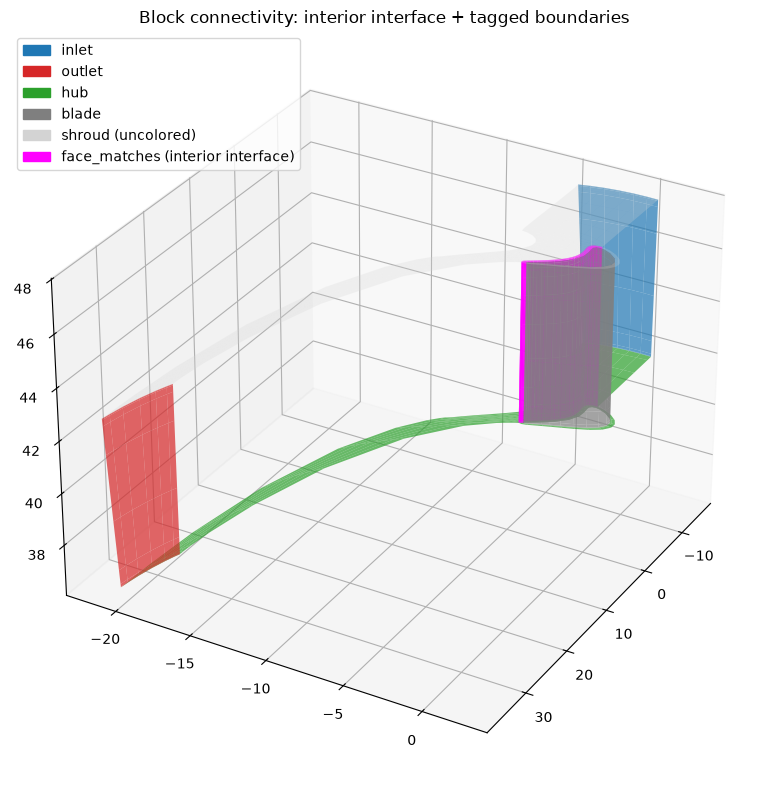

In [12]:
def _face_coords(block, lb, ub, stride=1):
    i0, i1 = sorted((lb[0], ub[0]))
    j0, j1 = sorted((lb[1], ub[1]))
    k0, k1 = sorted((lb[2], ub[2]))
    X = block.X[i0:i1 + 1:stride or 1, j0:j1 + 1:stride or 1, k0:k1 + 1:stride or 1]
    Y = block.Y[i0:i1 + 1:stride or 1, j0:j1 + 1:stride or 1, k0:k1 + 1:stride or 1]
    Z = block.Z[i0:i1 + 1:stride or 1, j0:j1 + 1:stride or 1, k0:k1 + 1:stride or 1]
    return np.squeeze(X), np.squeeze(Y), np.squeeze(Z)


import matplotlib.patches as mpatches

# blade/inlet/outlet/hub get their own color; shroud is deliberately left
# out of this dict (and so falls back to light gray below), otherwise its
# large area hides everything else in the plot.
surface_colors = {"inlet": "tab:blue", "outlet": "tab:red", "hub": "tab:green", "blade": "tab:gray"}

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

for f in outer_faces:
    block = blocks[f["block_index"]]
    name = surface_ids[str(f["id"])]
    X, Y, Z = _face_coords(block, f["lb"], f["ub"], stride=8)
    color = surface_colors.get(name, "lightgray")
    alpha = 0.7 if name in surface_colors else 0.25
    ax.plot_surface(X, Y, Z, color=color, alpha=alpha, shade=False, linewidth=0)

# face_matches drawn last, at full opacity and finer sampling, so the thin
# interior interface doesn't get lost behind the (much larger) boundary
# surfaces regardless of view angle.
for m in face_matches:
    b1 = blocks[m["block1"]["block_index"]]
    X, Y, Z = _face_coords(b1, m["block1"]["lb"], m["block1"]["ub"], stride=2)
    ax.plot_surface(X, Y, Z, color="magenta", alpha=1.0, shade=False, zorder=10)

ax.set_title("Block connectivity: interior interface + tagged boundaries")
ax.view_init(30, 30, 0)

legend_handles = [mpatches.Patch(color=c, label=n) for n, c in surface_colors.items()]
legend_handles.append(mpatches.Patch(color="lightgray", label="shroud (uncolored)"))
legend_handles.append(mpatches.Patch(color="magenta", label="face_matches (interior interface)"))
ax.legend(handles=legend_handles, loc="upper left")
plt.tight_layout()
plt.show()


## 4. Exporting to simulation

Every boundary is tagged now. Attach physics and see what the graph
actually looks like once it's built.


### Which node is a wall? Which is fluid?

This is the picture that actually answers that question -- not the YAML
file. Every node in the flattened graph carries a `point_bc_type`: wall,
inlet, outlet, periodic, or interior (fluid). Attach minimal physics with
the three BC dataclasses so `flatten_mesh` can resolve real types, then
color every non-fluid node by its type (plus a light random sample of
fluid nodes, just for context -- there are 2M+ of them, plotting all would
show nothing but a gray blob):


In [13]:
bcs = [
    Plot3DFlattenInletBC(name="inlet", surfaces=[1], total_pressure=101325.0, total_temperature=288.0),
    Plot3DFlattenOutletBC(name="outlet", surfaces=[2], back_pressure=90000.0),
    Plot3DFlattenWallBC(name="blade", surfaces=[3], thermal="adiabatic"),
    Plot3DFlattenWallBC(name="hub", surfaces=[4], thermal="adiabatic"),
    Plot3DFlattenWallBC(name="shroud", surfaces=[5], thermal="adiabatic"),
]

rotation_angle_rad = math.radians(360.0 / nblades)
periodicity_meta = {
    "nblades": nblades,
    "rotation_axis": "x",
    "rotation_angle_rad": rotation_angle_rad,
    "rotation_angle_deg": 360.0 / nblades,
    "transformation_matrix": create_rotation_matrix(rotation_angle_rad, "x").tolist(),
    "convention": "Face_B_points = (transformation_matrix @ Face_A_points.T).T",
}

fmesh = flatten_mesh(
    blocks, face_matches, outer_faces,
    periodic_faces=periodic_faces, periodicity=periodicity_meta,
    surface_ids=surface_ids, bcs=bcs,
)
print(fmesh.summary())


Calculating the volumes:   0%|          | 0/32 [00:00<?, ?it/s]

Calculating the volumes:   3%|▎         | 1/32 [00:00<00:06,  4.85it/s]

Calculating the volumes:   6%|▋         | 2/32 [00:00<00:06,  4.94it/s]

Calculating the volumes:   9%|▉         | 3/32 [00:00<00:05,  4.95it/s]

Calculating the volumes:  12%|█▎        | 4/32 [00:00<00:05,  4.95it/s]

...

Calculating the volumes:  96%|█████████▌| 50/52 [00:10<00:00,  4.69it/s]

Calculating the volumes:  98%|█████████▊| 51/52 [00:11<00:00,  4.72it/s]

Calculating the volumes: 100%|██████████| 52/52 [00:11<00:00,  4.71it/s]

Calculating the volumes: 100%|██████████| 52/52 [00:11<00:00,  4.62it/s]

FlatMesh: Nc=2212800 Nf=6678528 Nn=2280176
  total volume = 1471.51
  total boundary surface area = 658.311
  periodic faces = 26800
  boundary faces per surface:
    id=1 (inlet): 5200
    id=2 (outlet): 5200
    id=3 (blade): 25600
    id=4 (hub): 22128
    id=5 (shroud): 22128


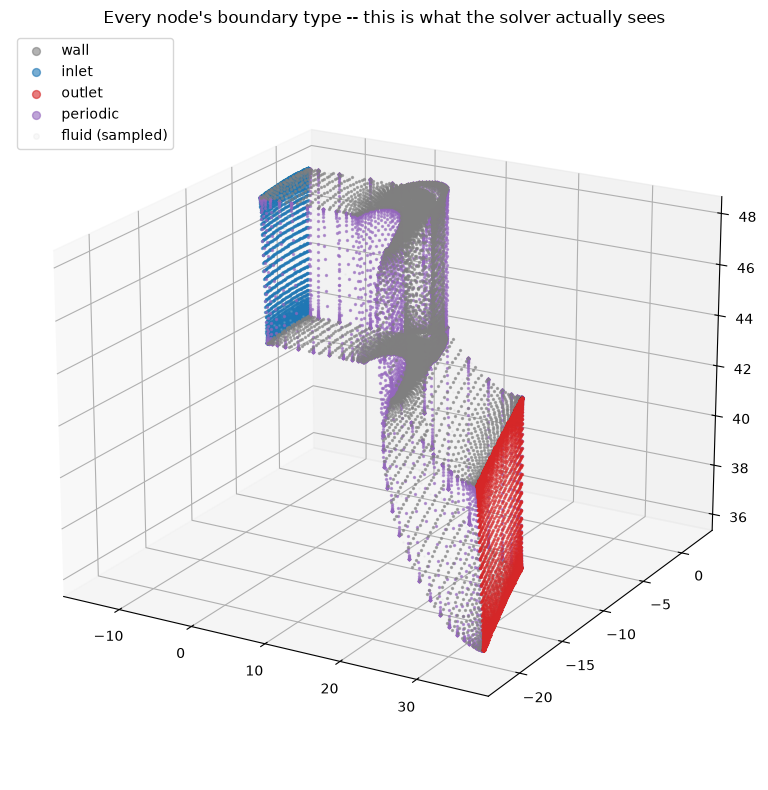

In [14]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

colors = {"wall": "tab:gray", "inlet": "tab:blue", "outlet": "tab:red", "periodic": "tab:purple"}
strides = {"wall": 6, "inlet": 1, "outlet": 1, "periodic": 6}
rng = np.random.default_rng(0)

for bc_code, name in fmesh.bc_type_legend.items():
    if name == "interior":
        continue
    idx = np.nonzero(fmesh.point_bc_type == bc_code)[0]
    if len(idx) == 0:
        continue
    idx = idx[::strides.get(name, 4)]
    pts = fmesh.points[idx]
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=2, color=colors.get(name, "black"),
              label=name, alpha=0.6, depthshade=False)

interior_code = [c for c, n in fmesh.bc_type_legend.items() if n == "interior"][0]
interior_idx = np.nonzero(fmesh.point_bc_type == interior_code)[0]
sample = rng.choice(interior_idx, size=min(3000, len(interior_idx)), replace=False)
pts = fmesh.points[sample]
ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=1, color="lightgray", alpha=0.15,
          label="fluid (sampled)", depthshade=False)

ax.set_title("Every node's boundary type -- this is what the solver actually sees")
ax.legend(loc="upper left", markerscale=4)
ax.view_init(elev=20, azim=-60)
plt.tight_layout()
plt.show()


### Writing what a solver reads

The physics -- pressure, temperature, wall type -- goes in a
`boundary_conditions:` YAML fragment. Only the fields you actually set are
written:


In [15]:
bc_yaml_path = os.path.join(OUT_DIR, "vspt_boundary_conditions.yaml")
yaml_text = write_boundary_conditions_yaml(bcs, bc_yaml_path)
print(yaml_text)


boundary_conditions:
- name: inlet
  type: inlet
  surfaces: [1]
  total_pressure: 101325.0
  total_temperature: 288.0
- name: outlet
  type: outlet
  surfaces: [2]
  back_pressure: 90000.0
- name: blade
  type: wall
  surfaces: [3]
  thermal: adiabatic
- name: hub
  type: wall
  surfaces: [4]
  thermal: adiabatic
- name: shroud
  type: wall
  surfaces: [5]
  thermal: adiabatic



A run deck ties it together: `mesh:` points at the grid, `boundary_conditions:`
is the YAML fragment above, pasted straight in:

```yaml
mesh:
  grid_file: "vspt.xyz"
  connectivity_file: "vspt.connectivity.json"
  format: formatted

boundary_conditions:
  - name: inlet
    type: inlet
    surfaces: [1]
    total_pressure: 101325.0
    total_temperature: 288.0
  - name: outlet
    type: outlet
    surfaces: [2]
    back_pressure: 90000.0
```

At load time, the solver reads the grid and (block-level) connectivity,
**builds its own internal per-cell graph** from those two pieces -- the
same graph this notebook built directly with `flatten_mesh` -- then
applies each `boundary_conditions:` entry to every cell face whose
surface `id` matches. Nothing here is solver-specific; the graph is the
same either way.


## What's next

You've built the graph a solver actually consumes: cells as nodes,
faces as directed `owner -> neighbor` edges, real geometry on every face,
and a boundary type on every node. The next step is to actually **use**
it -- a follow-on tutorial takes a single converging-diverging duct (the
same `duct_block` generator from Section 2, with a variable-radius
profile), flattens it the same way, and solves the Euler equations on the
resulting graph.


## Cleanup

In [16]:
import shutil

if os.path.exists(OUT_DIR):
    shutil.rmtree(OUT_DIR)
